# Understanding Confounding Variables: Ice Cream Sales and Drownings

This notebook demonstrates how a confounding variable can misleadingly suggest a causal relationship between two unrelated variables. We'll use a simulated dataset where both ice cream sales and drownings are influenced by a common factor: temperature.

## 1. Data Generation

We generate a synthetic dataset with 200 days of data. Here's how the variables are related:

*   `temp`: Daily temperature, normally distributed.
*   `ice`: Ice cream sales, which are directly driven by temperature.
*   `drown`: Drownings, which are also directly driven by temperature, but **not** by ice cream sales directly.

In [1]:
# @title
import numpy as np
import statsmodels.api as sm

rng = np.random.default_rng(42)
# Initialize a random number generator
# with a fixed seed for reproducibility, ensuring 
# the same random numbers are generated each time.
n = 200
# Define the number of data points (days) for our simulation.
temp   = rng.normal(30, 6, n)
# Generate 'n' random temperature values from a normal distribution
# with a mean of 30 and a standard deviation of 6. This represents daily temperatures.
ice    = 20 + 3.0 * temp + \
rng.normal(0, 12, n)
# Calculate ice cream sales: This is dependent on temperature (3.0 * temp),
# plus some random noise (normally distributed with mean 0, std_dev 12).
# This simulates ice cream sales increasing with temperature.
drown  = 2 + 0.5 * temp + \
rng.normal(0, 3, n)
# Calculate drownings: This is also dependent on temperature (0.5 * temp),
# plus some random noise (normally distributed with mean 0, std_dev 3).
# Importantly, drownings are NOT directly dependent on ice cream sales, but both are driven by temperature.
import pandas as pd

# Create a DataFrame for 'temp', 'ice', and 'drown' for a user-friendly display
df_values = pd.DataFrame({
    'Temperature (Celsius)': temp,
    'Ice Cream Sales (Units)': ice,
    'Drownings (Count)': drown
})

print("First 10 values for Temperature, Ice Cream Sales, and Drownings:")
display(df_values.head(10))
# Calculate and print the Pearson
# correlation coefficient between ice
# cream sales and drownings
print("Pearson r (ice vs drown):")
print(np.corrcoef(ice, drown)[0, 1])   
# Expected to be around 0.51, showing an apparent relationship

First 10 values for Temperature, Ice Cream Sales, and Drownings:


,Temperature (Celsius),Ice Cream Sales (Units),Drownings (Count)
0,31.828302,119.535802,17.375317
1,23.760095,108.170068,14.470376
2,34.502707,124.595140,21.712939
3,35.643388,134.657430,18.640471
4,18.293789,50.279301,12.710396
5,22.186923,85.976148,12.295945
6,30.767042,102.182364,17.030895
7,28.102544,89.681877,18.539829
8,29.899193,99.159751,10.970415
9,24.881736,90.635728,10.551451


Pearson r (ice vs drown):
0.5077546374406644


## 2. Initial Observation: Ice Cream Sales vs. Drownings

When we look at the relationship between ice cream sales and drownings directly, we observe a strong positive correlation. More ice cream sales appear to be associated with more drownings, which looks damning at first glance.

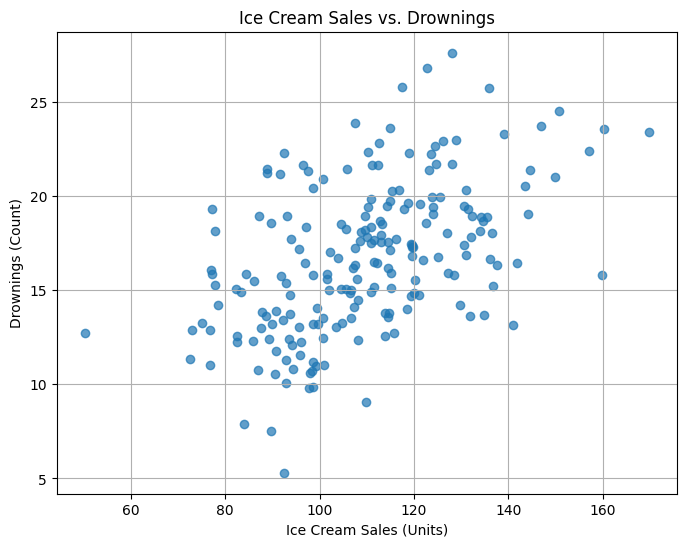

Two hundred days of data.More ice cream, more drownings.Looks damning.


In [2]:
# @title
# Import matplotlib for plotting capabilities.
import matplotlib.pyplot as plt

# Create a scatter plot of ice cream sales vs. drownings.
plt.figure(figsize=(8, 6))
# Define the size of the plot figure.
plt.scatter(ice, drown, alpha=0.7)
# Plot 'ice' on the x-axis and 'drown' on the y-axis.
# 'alpha=0.7' makes the points slightly transparent for better visualization of overlapping points.
plt.title('Ice Cream Sales vs. Drownings')
# Set the title of the plot.
plt.xlabel('Ice Cream Sales (Units)')
# Label the x-axis.
plt.ylabel('Drownings (Count)')
# Label the y-axis.
plt.grid(True)
# Add a grid to the plot for easier reading of values.
plt.show()
# Display the generated plot.

print('Two hundred days of data.'
+ 'More ice cream, more drownings.'
+ 'Looks damning.')

## 3. Quantifying the Relationship: Pearson Correlation

Let's calculate the Pearson correlation coefficient between ice cream sales and drownings. A coefficient of around 0.51 indicates a clear, moderate positive linear relationship.

In [3]:
# @title
# Calculate and print the Pearson correlation coefficient
pearson_r = np.corrcoef(ice, drown)[0,1]
print(f"Pearson r (ice vs drown): \
 {pearson_r:.2f} — a clear, moderate relationship.")

Pearson r (ice vs drown):  0.51 — a clear, moderate relationship.


## 4. Simple Linear Regression: Ice Cream as Predictor

Now, let's fit a simple linear regression model where ice cream sales are used to predict drownings. This model suggests that for every unit increase in ice cream sales, drownings increase by approximately 0.103. The R-squared value indicates that about 26% of the variance in drownings can be explained by ice cream sales.

In [4]:
# Fit a simple linear regression model (m1) where 'ice' predicts 'drown'.
# sm.OLS (Ordinary Least Squares) is used for linear regression.
# sm.add_constant(ice) adds a constant (intercept) term to the ice cream sales data,
# which is necessary for OLS models to estimate an intercept.
m1 = sm.OLS(drown, sm.add_constant(ice)).fit()

# Fit a multiple linear regression model (m2) where both 'ice' and 'temp' predict 'drown'.
# np.column_stack([ice, temp]) combines the 'ice' and 'temp' arrays into a single 2D array
# to be used as independent variables.
m2 = sm.OLS(drown, sm.add_constant(np.column_stack([ice, temp]))).fit()

# Print the estimated parameters (coefficients) and R-squared value for m1.
print(m1.params, m1.rsquared)                       
# ice coef ~0.103, R² ~0.26
# Print the estimated parameters, R-squared, and 
# Adjusted R-squared for m2.
print(m2.params, m2.rsquared, m2.rsquared_adj)       
# ice ~0.008, temp ~0.451, R² ~0.40, adj ~0.398

[5.35475264 0.10346645] 0.25781477184250035
[2.40463409 0.00770654 0.45122444] 0.4036910123526004 0.3976371140008501


In [5]:
# Display the parameters and R-squared for the one-variable model (m1)
print("One-variable model (ice cream only):")
print(f"  Ice Cream Coefficient: {m1.params[1]:.3f}") 
# Accessing the coefficient for 'ice'
print(f"  R-squared: {m1.rsquared:.2f}")
print('A one-variable model says: every extra unit of' +
'ice cream adds about a tenth of a drowning.')

One-variable model (ice cream only):
  Ice Cream Coefficient: 0.103
  R-squared: 0.26
A one-variable model says: every extra unit ofice cream adds about a tenth of a drowning.


## 5. Introducing a Confounding Variable: Temperature

Now, we'll add temperature to our model as an additional predictor. Even though we are using the exact same data for ice cream and drownings, including temperature reveals the true underlying relationship. Temperature is the real driver for both ice cream sales and drownings.

In [8]:
# Display the parameters, R-squared, and Adjusted R-squared for the two-variable model (m2)
print("Two-variable model (ice cream + temperature):")
print(f"  Constant: {m2.params[0]:.3f}")
print(f"  Ice Cream Coefficient: {m2.params[1]:.3f}") 
# Accessing the coefficient for 'ice'
print(f"  Temperature Coefficient: {m2.params[2]:.3f}")
# Accessing the coefficient for 'temp'
print(f"  R-squared: {m2.rsquared:.2f}")
print(f"  Adjusted R-squared: {m2.rsquared_adj:.2f}")

print('\nIce cream\'s effect collapses to basically nothing.' +
'Temperature takes the credit — because it\'s the real driver.')
print('And the model explains far more overall. That\'s '+
'holding temperature constant doing its job.')

Two-variable model (ice cream + temperature):
  Constant: 2.405
  Ice Cream Coefficient: 0.008
  Temperature Coefficient: 0.451
  R-squared: 0.40
  Adjusted R-squared: 0.40

Ice cream's effect collapses to basically nothing.Temperature takes the credit — because it's the real driver.
And the model explains far more overall. That's holding temperature constant doing its job.


# Demo 2 — Junk Variable Test: R² vs. Adjusted R²


In [9]:
rng_junk = np.random.default_rng(5)
# Initialize a new random number generator with a different seed (5) for reproducibility.
junk = rng_junk.normal(0, 1, n)
# Generate 'n' random numbers from a standard normal distribution (mean 0, std_dev 1).
# This 'junk' variable is pure random noise and 
# should have no real predictive power.

m3 = sm.OLS(drown, sm.add_constant(np.column_stack([ice, temp, junk]))).fit()
# Fit a new multiple linear regression model (m3) 
# including 'ice', 'temp', and the 'junk' variable.
# This will allow us to observe how R-squared and Adjusted R-squared behave with an irrelevant variable.

print("Two-variable model (ice cream + temperature):")
print(f"  R-squared: {m2.rsquared:.3f}")
print(f"  Adjusted R-squared: {m2.rsquared_adj:.3f}")
# Print the R-squared and Adjusted R-squared for the model without the junk variable (m2).

print("\nModel with Junk Variable (ice cream + temperature + junk):")
print(f"  R-squared: {m3.rsquared:.3f}")
print(f"  Adjusted R-squared: {m3.rsquared_adj:.3f}")
# Print the R-squared and Adjusted R-squared for the 
# model including the junk variable (m3).

print('\nPlain R² went up — it rewards you for adding \
anything. Adjusted R² went down — it saw through it.')
# A concluding statement to highlight the observed
# behavior of R-squared vs. Adjusted R-squared.

Two-variable model (ice cream + temperature):
  R-squared: 0.404
  Adjusted R-squared: 0.398

Model with Junk Variable (ice cream + temperature + junk):
  R-squared: 0.406
  Adjusted R-squared: 0.397

Plain R² went up — it rewards you for adding anything. Adjusted R² went down — it saw through it.


# Demo 3 — Multicollinearity: Two Thermometers


In [10]:
rng_temp_f = np.random.default_rng(6) 
# Use a different seed for the noise
temp_f = (temp * 9/5) + 32 + rng_temp_f.normal(0, 0.1, n) 
# Convert temp to Fahrenheit and add a tiny bit of noise

In [11]:
print(f"Correlation between temp and temp_f: \
{np.corrcoef(temp, temp_f)[0, 1]:.3f}")
print("Two inputs that are basically the same measurement.")

Correlation between temp and temp_f: 1.000
Two inputs that are basically the same measurement.


In [12]:
# Fit a multiple linear regression model (m4) using both temp
# (Celsius) and temp_f (Fahrenheit) to predict drownings.
# np.column_stack combines the two highly correlated 
# temperature variables.
m4 = sm.OLS(drown, 
    sm.add_constant(np.column_stack([temp, temp_f]))).fit()

print("Model with both Celsius and Fahrenheit temperatures:")
print(f"  Celsius Coefficient (temp): {m4.params[1]:.3f}")
print(f"  Fahrenheit Coefficient (temp_f): {m4.params[2]:.3f}")
print("Now the model has to split the credit between them — \
and it can't do it sensibly.")

Model with both Celsius and Fahrenheit temperatures:
  Celsius Coefficient (temp): -2.278
  Fahrenheit Coefficient (temp_f): 1.528
Now the model has to split the credit between them — and it can't do it sensibly.


In [13]:
# Re-generate the data with a new random seed (1) to show instability in coefficients.
rng_new = np.random.default_rng(1)
new_temp = rng_new.normal(30, 6, n)
new_temp_f = (new_temp * 9/5) + 32 + rng_new.normal(0, 0.1, n)
new_drown = 2 + 0.5 * new_temp + rng_new.normal(0, 3, n)

# Re-fit the model (m5) with the new random sample of data.
m5 = sm.OLS(new_drown, sm.add_constant(np.column_stack([new_temp, new_temp_f]))).fit()

print("\nRe-running with a different random seed (seed 1):")
print(f"  Celsius Coefficient (new_temp): {m5.params[1]:.3f}")
print(f"  Fahrenheit Coefficient (new_temp_f): {m5.params[2]:.3f}")
print("Same setup, new random sample — and one coefficient shoots up while the other goes negative. The pair is unstable, even though the model's predictions barely change.")


Re-running with a different random seed (seed 1):
  Celsius Coefficient (new_temp): 12.826
  Fahrenheit Coefficient (new_temp_f): -6.816
Same setup, new random sample — and one coefficient shoots up while the other goes negative. The pair is unstable, even though the model's predictions barely change.


That's multicollinearity. Trust the prediction, not the individual coefficients.

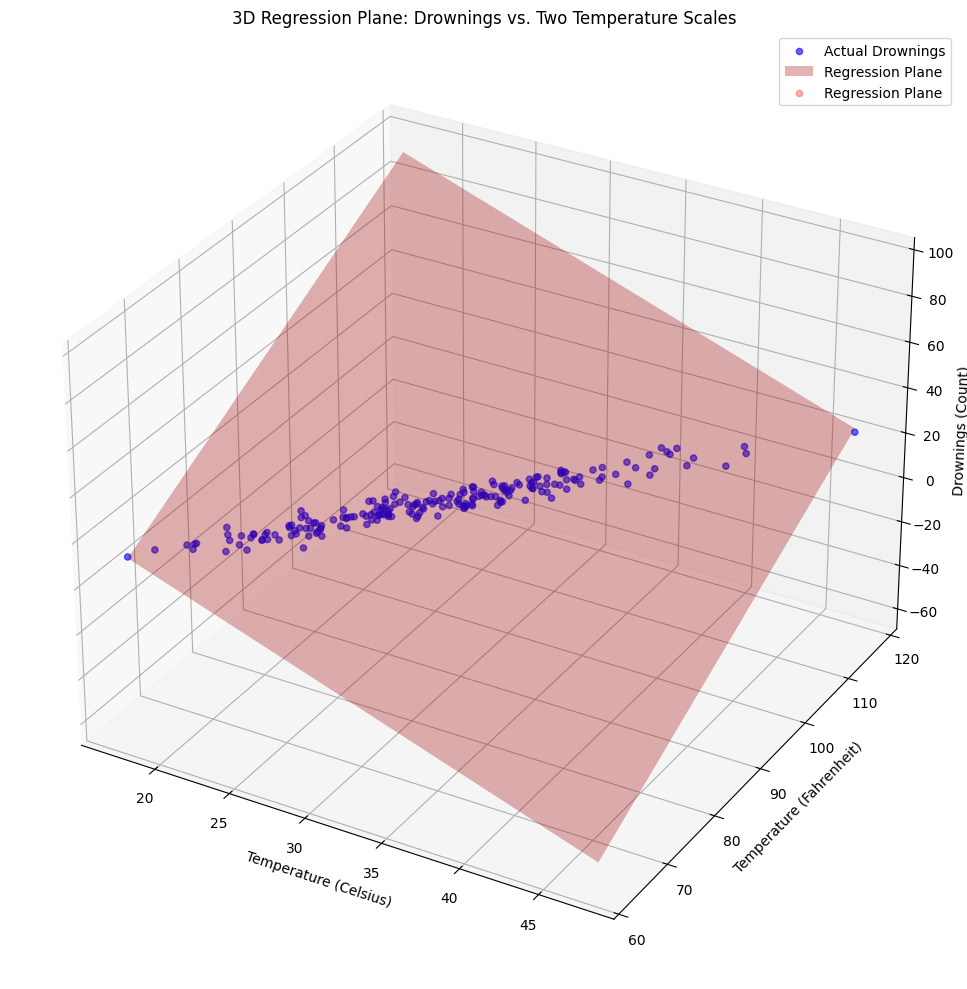

In [14]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Create a figure and a 3D Axes object
fig = plt.figure(figsize=(20, 10))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot the actual data points
ax.scatter(temp, temp_f, drown, c='blue', marker='o', alpha=0.6, label='Actual Drownings')

# Create a meshgrid for the surface plot (the regression plane)
X = np.linspace(temp.min(), temp.max(), 10)
Y = np.linspace(temp_f.min(), temp_f.max(), 10)
X, Y = np.meshgrid(X, Y)

# Calculate the predicted 'drown' values using the coefficients from model m4
# m4.params[0] is the intercept
# m4.params[1] is the coefficient for temp (our X)
# m4.params[2] is the coefficient for temp_f (our Y)
Z = m4.params[0] + m4.params[1] * X + m4.params[2] * Y

# Plot the regression plane
ax.plot_surface(X, Y, Z, color='red', alpha=0.3,
                label='Regression Plane')

# Set labels and title
ax.set_xlabel('Temperature (Celsius)')
ax.set_ylabel('Temperature (Fahrenheit)')
ax.set_zlabel('Drownings (Count)')
ax.set_title('3D Regression Plane: Drownings vs. \
Two Temperature Scales')

# For the legend, plot dummy points on the surface
ax.scatter([], [], [], color='red', alpha=0.3,
           label='Regression Plane')
ax.legend()

plt.tight_layout()
plt.show()

This 3D scatterplot visually demonstrates multicollinearity by showing the relationship between two highly correlated predictors (`Temperature (Celsius)` and `Temperature (Fahrenheit)`) and the response variable (`Drownings`). The regression plane illustrates how the model attempts to fit the data, even with redundant information from the predictors.